# 80 - Visualizar clusters TF-IDF + K-Means

Este notebook abre uma execu??o do notebook 70 e projeta as descri??es em duas dimens?es com TruncatedSVD. Cada ponto ? uma descri??o, a cor indica o cluster e a cruz marca o centroide projetado. A proje??o ? uma aproxima??o para inspe??o: dist?ncias no plano n?o substituem a dist?ncia no espa?o TF-IDF original.

Execute as c?lulas em ordem. Nenhuma depend?ncia nova ? necess?ria.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import TruncatedSVD

from nofis_classifier.clustering import load_local_model
from nofis_classifier.paths import find_project_root
from nofis_classifier.schema import DESCRIPTION_NORMALIZED, FREQUENCY

pd.set_option("display.max_colwidth", 120)
PROJECT_ROOT = find_project_root()
GRID_DIR = PROJECT_ROOT / "reports" / "grid_tfidf_kmeans"


## Selecionar a execu??o e o experimento

A lista abaixo mostra execu??es que j? possuem `candidates.csv`. Escolha o ?ndice da execu??o mais recente (ou outra) e depois o experimento listado. Os modelos permanecem em `models/`; este notebook apenas os carrega.

In [8]:
run_dirs = sorted(
    [path for path in GRID_DIR.glob("*") if (path / "candidates.csv").exists()],
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
if not run_dirs:
    raise FileNotFoundError("Nenhuma execu??o encontrada. Execute primeiro o notebook 70.")

runs = pd.DataFrame({"indice": range(len(run_dirs)), "execucao": [p.name for p in run_dirs], "caminho": [str(p) for p in run_dirs]})
display(runs[["indice", "execucao"]])
RUN_INDEX = 0
REPORT_DIR = run_dirs[RUN_INDEX]
candidates = pd.read_csv(REPORT_DIR / "candidates.csv")
display(candidates[["experiment_id", "config_name", "k", "seed"]])
EXPERIMENT_ID = candidates.iloc[0]["experiment_id"]  # altere para outro candidato


,indice,execucao
0,0,202501-202504_20260927T163113Z_3df937b0
1,1,202501-202504_20260926T194715Z_7df01672


,experiment_id,config_name,k,seed
0,char_wb_3_5_df2_max30000_k80_seed2026,char_wb_3_5_df2_max30000,80,2026
1,char_wb_3_5_df5_max30000_k80_seed123,char_wb_3_5_df5_max30000,80,123
2,char_wb_3_5_df5_max30000_k60_seed2026,char_wb_3_5_df5_max30000,60,2026
3,word_1_1_df5_max10000_k10_seed123,word_1_1_df5_max10000,10,123


In [9]:
candidate = candidates.loc[candidates.experiment_id.eq(EXPERIMENT_ID)].iloc[0]
review_dir = REPORT_DIR / "review" / EXPERIMENT_ID
assignments_path = review_dir / "assignments.csv"
if not assignments_path.exists():
    raise FileNotFoundError(f"Atribui??es n?o encontradas: {assignments_path}. Execute a se??o 5 do notebook 70.")
assignments = pd.read_csv(assignments_path)
review_path = review_dir / "cluster_review.csv"
review = pd.read_csv(review_path) if review_path.exists() else pd.DataFrame()
vectorizer = load_local_model(candidate.vectorizer_path)
model = load_local_model(candidate.model_path)

print(f"Experimento: {EXPERIMENT_ID} | descri??es: {len(assignments):,} | clusters: {model.n_clusters}")
display(review.sort_values("frequencia_total", ascending=False).head(10) if not review.empty else assignments.groupby("cluster").size().rename("descricoes").to_frame())


Experimento: char_wb_3_5_df2_max30000_k80_seed2026 | descri??es: 27,500 | clusters: 80


,experiment_id,cluster,termos_relevantes,exemplos_centrais,exemplos_distantes,exemplos_aleatorios,descricoes_unicas,frequencia_total,sem_vocabulario,avaliacao_qualitativa,rotulo_humano,observacoes
0,char_wb_3_5_df2_max30000_k80_seed2026,0,0g | de | de | pa | ma | co | ra | ca | de | sa | 00g | po | 00g | ao | co,lixeira plastica compostela de 20l branca com pedal | massa para pastel pct 500g | lixeira grande em plastico 100lit...,mumu | 004 | wash r | umbu | zapp qi 620 | 003,abs intimus gel seca c a l16p14 | bisc orquidea agua e sal | capeleti | bergamota pokan | sorvete 2lt napolitano ita...,6621,25571,0,REVISAR,NaN,NaN
2,char_wb_3_5_df2_max30000_k80_seed2026,7,kg | kg | kg | alh | alho | alho | alho | alh | lho | lho | ho | al | ao | mela | mela,alho kg 1 kg | alho kg | v alho kg | alho kg v | alho em po kg | alho poro kg 1 kg,quimiway attaway podium 1 kg | epac black xl inve 8 kg 00127 | rc nutrisitio avestruz sc 25 kg | coxa friato envelop...,alho kg | f limao kg | noz moscada do produtor kg | granola 1 kg | uva crimsom kg 1 kg | alho desc do sitio 1kg,913,12481,0,REVISAR,NaN,NaN
33,char_wb_3_5_df2_max30000_k80_seed2026,14,ata | atat | batat | bata | bata | tat | tata | atata | tata | bat | bat | ata | ba | ta | palha,batata | batata kg | batata doce | batata doce kg | batata palha | batata palha kg,verdura batatinha | bata em flocos | batata processada especie inglesa tipo formato palha tipo frita apresentacao pr...,batata lavada kg | batata asterix | batata extra kg | batata monaliza lavada kg | batata processada especie inglesa ...,264,4436,0,REVISAR,NaN,NaN
8,char_wb_3_5_df2_max30000_k80_seed2026,65,pim | pime | pime | molho | molh | molh | pimen | mol | menta | pim | olho | olho | mol | mo | enta,molho pimenta | molho de pimenta | molho pimenta 150 ml | molho de pimenta 150 ml | molho pimenta 150ml | molho de p...,molho barbecue culinario embalagem de aproximadamente 3 2 kg ruah | molho 3 em 1 hellmanns bisnaga | molho tipo maio...,molho shoyu chinezinho | temp dusul pt completo s pimenta | molho madeira 210g | molho de pimenta 900 ml | molho p s...,437,4410,0,REVISAR,NaN,NaN
9,char_wb_3_5_df2_max30000_k80_seed2026,63,natur | natu | atura | natu | atur | atu | nat | nat | na | tura | tur | ura | in | tura | in,uva in natura | maca in natura | uva in natura kg 1 kg | alho in natura | alho in natura kg | leite in natura,sab palmolive naturals 150g cacau e mant ka | verdura in nartura tipo rucula | castanha caju natural excelencia 150g...,maca fugi in natura kg | verdura in natura alface lisa | fruta tipo melao amarelo apresentacao natural | maca in nat...,437,4210,0,REVISAR,NaN,NaN
24,char_wb_3_5_df2_max30000_k80_seed2026,12,opo | copo | cop | copo | cop | opo | copo | alfac | lface | lfac | face | alfa | alfa | face | alf,alface un | alface | alface c | alface 1 | alface kg | alface und,00000000000350 brocolis | brocolis hibrido un selecionado | copo plast premium 300ml 100pc bompack 7 900x50 800 | co...,qa copo desc qualita 200ml | copo desc 180ml cristalcopo abnt | copo plast premium 300ml 100pc bompack 7 900x50 800 ...,310,3902,0,REVISAR,NaN,NaN
50,char_wb_3_5_df2_max30000_k80_seed2026,39,ana | nan | bana | anana | bana | banan | anan | nana | nana | ban | ban | ana | ba | na | prata,banana | banana kg | doce banana | banana prata | banana prata kg | banana kg prata,banana prata pnae agricultura familiar entrega na macaibaeaj | impact banana 200ml emb esp l4334046001 v1 2 26 | ban...,bananaprata | banana prata coopgrande | banana prata fruta | banana kg katura feira quadri kg | doce de banana | doc...,192,3740,0,REVISAR,NaN,NaN
58,char_wb_3_5_df2_max30000_k80_seed2026,37,egume | egum | legum | legu | legu | leg | gume | egu | gum | leg | ume | enour | noura | ceno | enou,legume in natura cenoura | legume in natura tipo cenoura | legume tipo cenoura | cenoura comum legume kg | cenoura c...,cortador fatiador legumes c suporte plast cx n 730 plasbrink 730 | legume processado tipo mandioca formato palito pr...,caldo kn

## Projetar em duas dimens?es

TruncatedSVD trabalha diretamente com a matriz esparsa TF-IDF. Para manter o gr?fico leg?vel, o c?digo seleciona no m?ximo `MAX_POINTS_PER_CLUSTER` descri??es por grupo; a amostra ? fixa e reprodut?vel. O resumo de frequ?ncias continua usando todas as descri??es.

In [10]:
MAX_POINTS_PER_CLUSTER = 500
RANDOM_STATE = 42

sampled_indexes = []
for _, cluster_rows in assignments.groupby("cluster", sort=True):
    sampled_indexes.extend(
        cluster_rows.sample(
            n=min(len(cluster_rows), MAX_POINTS_PER_CLUSTER),
            random_state=RANDOM_STATE,
        ).index
    )
plot_rows = assignments.loc[sampled_indexes].reset_index(drop=True)
plot_matrix = vectorizer.transform(plot_rows[DESCRIPTION_NORMALIZED].fillna(""))
svd = TruncatedSVD(n_components=2, n_iter=7, random_state=RANDOM_STATE)
coordinates = svd.fit_transform(plot_matrix)
centroid_coordinates = svd.transform(model.cluster_centers_)
plot_rows[["dimensao_1", "dimensao_2"]] = coordinates

print(f"Vari?ncia explicada pelas duas dimens?es: {svd.explained_variance_ratio_.sum():.1%}")


Vari?ncia explicada pelas duas dimens?es: 1.5%


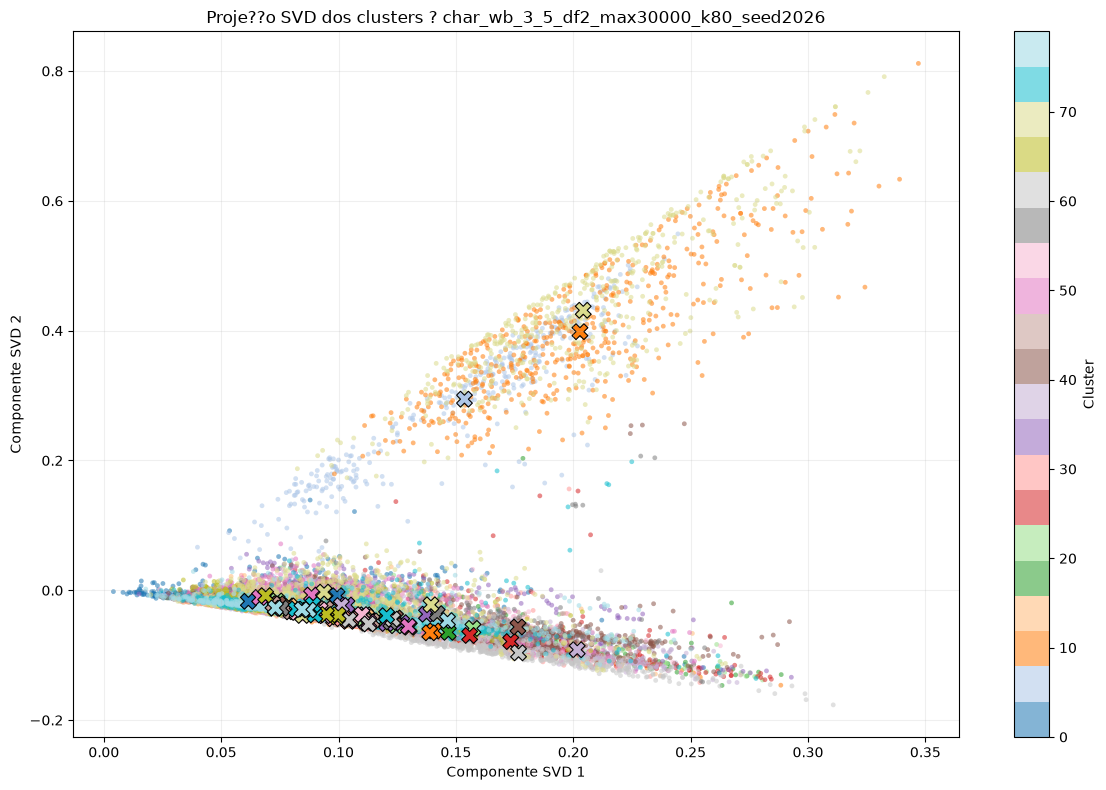

In [11]:
cluster_sizes = assignments.groupby("cluster").agg(
    descricoes=(DESCRIPTION_NORMALIZED, "size"),
    frequencia_total=(FREQUENCY, "sum"),
).sort_values("frequencia_total", ascending=False)
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    plot_rows["dimensao_1"], plot_rows["dimensao_2"],
    c=plot_rows["cluster"], cmap="tab20", s=12, alpha=0.55, linewidths=0,
)
ax.scatter(centroid_coordinates[:, 0], centroid_coordinates[:, 1], marker="X", s=130,
           c=np.arange(model.n_clusters), cmap="tab20", edgecolors="black", linewidths=0.8)
ax.set(title=f"Proje??o SVD dos clusters ? {EXPERIMENT_ID}", xlabel="Componente SVD 1", ylabel="Componente SVD 2")
ax.grid(alpha=0.2)
fig.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()


## Comparar tamanho dos clusters

Este gr?fico usa todas as atribui??es e pode revelar grupos muito maiores ou menores que os demais. Selecione um cluster na pr?xima c?lula para ver seus termos e exemplos.

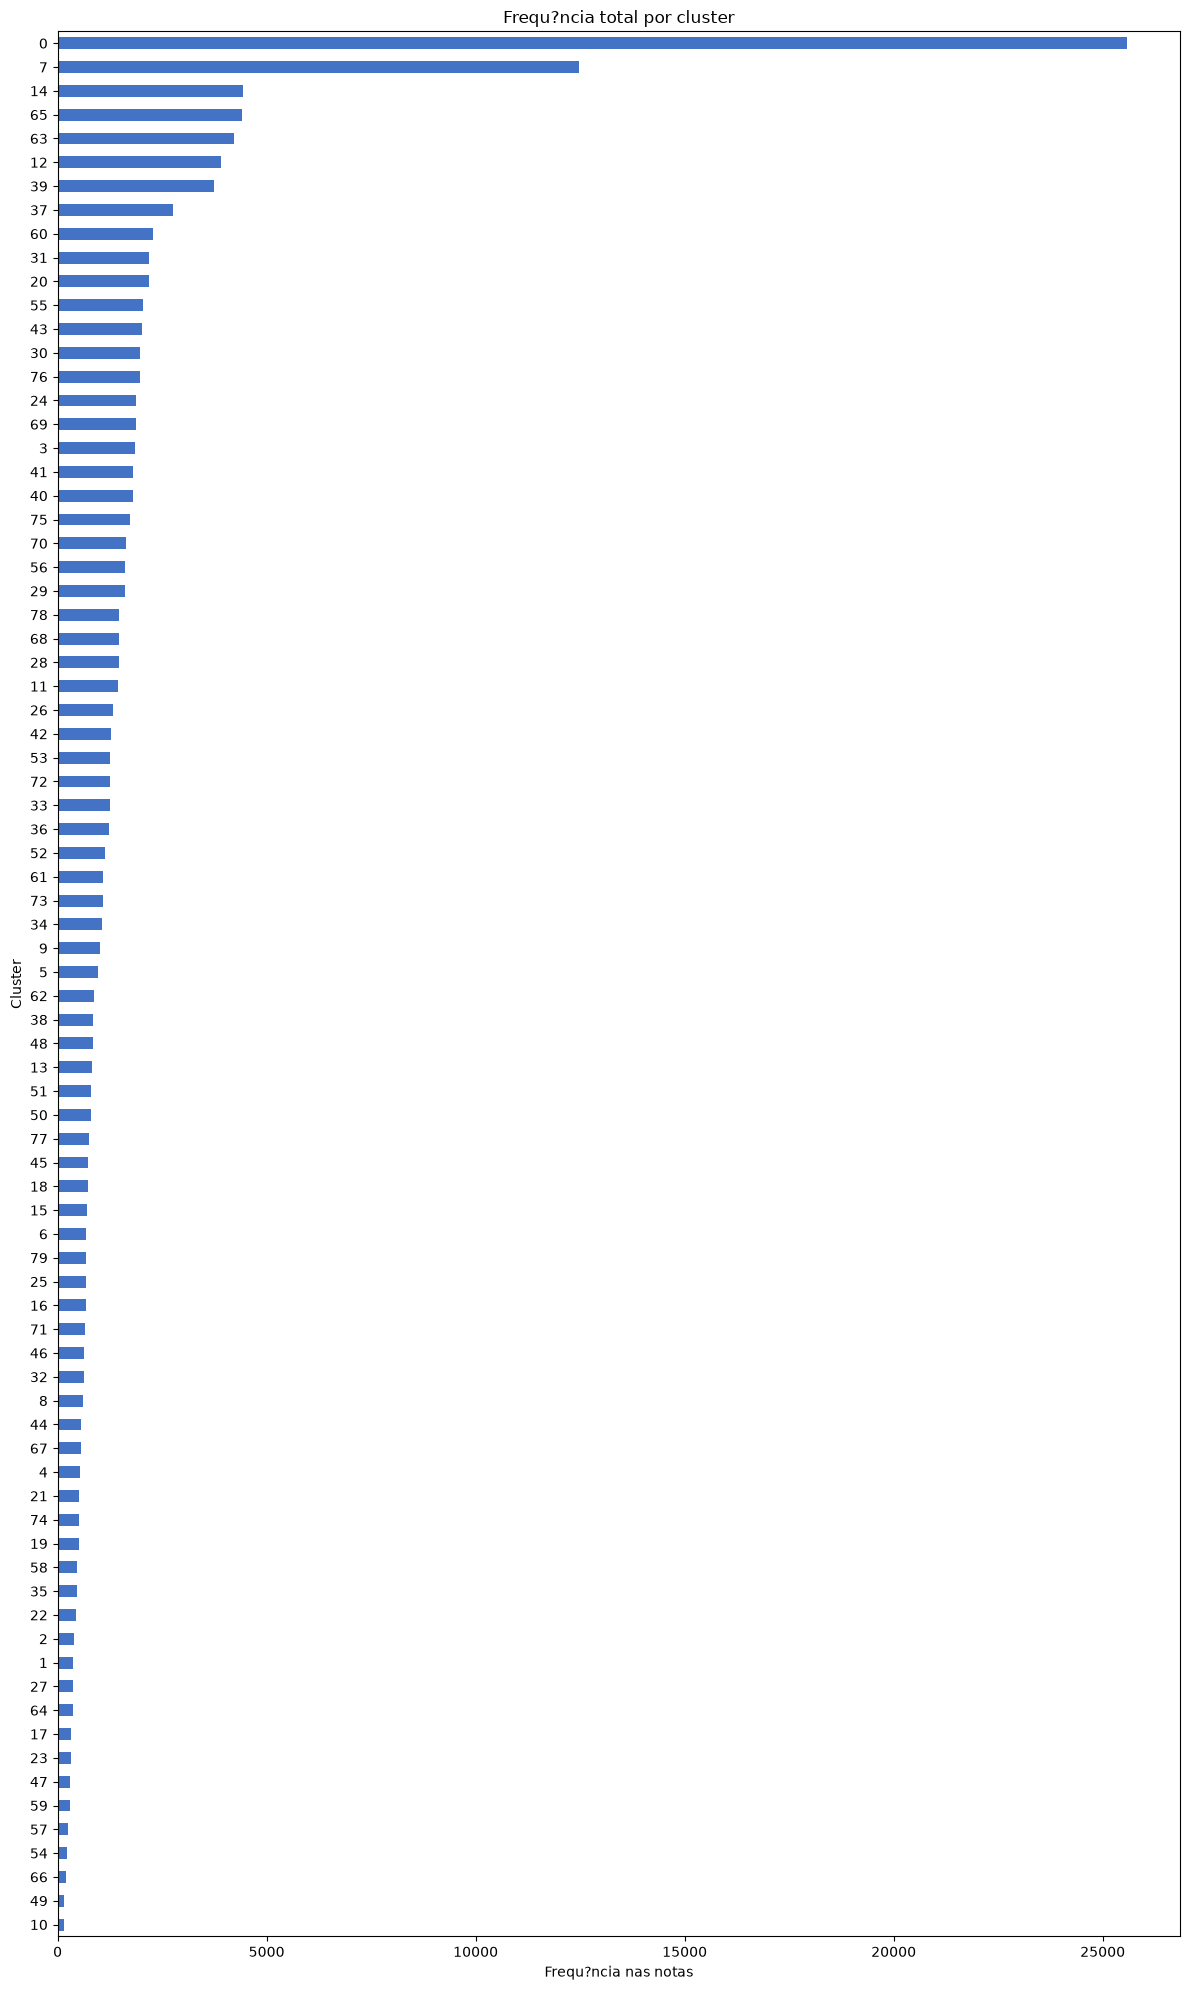

In [12]:
fig, ax = plt.subplots(figsize=(12, max(4, model.n_clusters * 0.25)))
cluster_sizes.sort_values("frequencia_total").plot.barh(y="frequencia_total", ax=ax, legend=False, color="#4472C4")
ax.set(title="Frequ?ncia total por cluster", xlabel="Frequ?ncia nas notas", ylabel="Cluster")
plt.tight_layout()
plt.show()


In [17]:
CLUSTER_ID = int(cluster_sizes.index[0])
cluster_points = assignments.loc[assignments.cluster.eq(CLUSTER_ID)]
if not review.empty:
    display(review.loc[review.cluster.eq(CLUSTER_ID)].T)
cols = [c for c in ["cluster", DESCRIPTION_NORMALIZED, "termos_tfidf", "distancia_centroide", FREQUENCY] if c in cluster_points.columns]
display(cluster_points.sort_values("distancia_centroide" if "distancia_centroide" in cols else DESCRIPTION_NORMALIZED)[cols].head(30))


,0
experiment_id,char_wb_3_5_df2_max30000_k80_seed2026
cluster,0
termos_relevantes,0g | de | de | pa | ma | co | ra | ca | de | sa | 00g | po | 00g | ao | co
exemplos_centrais,lixeira plastica compostela de 20l branca com pedal | massa para pastel pct 500g | lixeira grande em plastico 100lit...
exemplos_distantes,mumu | 004 | wash r | umbu | zapp qi 620 | 003
exemplos_aleatorios,abs intimus gel seca c a l16p14 | bisc orquidea agua e sal | capeleti | bergamota pokan | sorvete 2lt napolitano ita...
descricoes_unicas,6621
frequencia_total,25571
sem_vocabulario,0
avaliacao_qualitativa,REVISAR


,cluster,descricao_normalizada,distancia_centroide,frequencia
16121,0,lixeira plastica compostela de 20l branca com pedal,0.981811,2
17211,0,massa para pastel pct 500g,0.982491,1
16086,0,lixeira grande em plastico 100litros,0.982509,1
2938,0,balde plastico com alca em metal capacidade 10 litros,0.982717,1
7845,0,creme de cebola em po 500g,0.983097,1
17209,0,massa para pastel fresca 500g,0.983137,1
17138,0,massa de pastel 500g,0.983357,5
26829,0,uva passa preta sem semente emb primaria 500g a 1kg,0.983493,1
17203,0,massa para lasanha pct 500g,0.983551,1
2936,0,balde plastico capacidade 20 litros com alca metalica arqplast,0.983660,6
